# 08 — LSTM: Learning Nonlinear Temporal Patterns

## Where this sits on the ladder

```
05a  Components (level, trend, seasonality, noise)
05b  Baselines (Naive, Seasonal Naive, MA — frozen 112k pts/dataset)
06   Exponential Smoothing (SES/DES/TES — explicit states)
07   ARIMA/SARIMA (autocorrelation, stationarity, seasonal differencing)
08   LSTM  ←  you are here — nonlinear sequence learning
09   LLM
10+  Comparison, inventory, business
```

> **Research question for this notebook:** Does a recurrent neural network that learns nonlinear temporal relationships from pooled series improve forecasts over statistical models, and where does its flexibility become a liability (especially on sparse/intermittent M5)?

**How to read this notebook:** `Concept → Visual intuition → Architecture/gates → Mathematics → Worked numerical example → Hyperparameters → Assumptions → What it captures/cannot → Limitations → Inventory/business example → Implementation (leakage-safe, global) → Rolling evaluation → Results → Failure analysis`. Every chart answers a question.

**Frozen primary design (unchanged):** M5 = 500 stratified series, Store Item Demand = 500 series (all), common window 2013-01-01 → 2016-05-22 (1,238 days), horizon $h=28$, 8 weekly rolling origins (2016-03-01 … 2016-04-19), metrics MAE/RMSE/sMAPE/WAPE, seed 42. This notebook uses **ONE GLOBAL LSTM per dataset/origin** pooling the 500 series with **direct 28-day multi-output** forecasting — not per-series LSTMs. All 500×8×28 = 112,000 forecast points per dataset are still produced and evaluated identically to 05b/06/07.

**Pre-read:** 05a (components), 07 (ARIMA) for the statistical view this notebook extends.

## 0. Environment

Standardise paths, style, seeds, libraries. No fitting yet.

In [1]:
import sys, pathlib, json, warnings, hashlib, time
warnings.filterwarnings("ignore")
sys.path.insert(0, str(pathlib.Path(".").resolve()))
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
try:
    get_ipython().run_line_magic("matplotlib", "inline")
except:
    pass
from pathlib import Path

for _cand in [Path(".").resolve(), Path("..").resolve(), Path.cwd(), Path.cwd().parent]:
    if (_cand / "02_data").exists():
        PROJ = _cand
        break
else:
    PROJ = Path("..").resolve()
sys.path.insert(0, str(PROJ / "11_src"))
from plotting import apply_style
apply_style()

import torch
import torch.nn as nn

SEED = 42
rng = np.random.default_rng(SEED)
torch.manual_seed(SEED)
np.random.seed(SEED)

FIG_EDU = PROJ / "07_figures/model_explanations/lstm"
FIG_EXP = PROJ / "07_figures/lstm"
RES = PROJ / "06_results/lstm"
for d in [FIG_EDU, FIG_EXP, RES]:
    d.mkdir(parents=True, exist_ok=True)

print(f"Project root: {PROJ}")
print(f"Torch: {torch.__version__} | Device: cpu | Seed: {SEED}")
print(f"Educational figs: {FIG_EDU}")
print(f"Experimental figs: {FIG_EXP}")
print(f"Results: {RES}")

Project root: D:\Brain\07_Research\AI-INVENTORY-OPTIMIZATION
Torch: 2.13.0+cpu | Device: cpu | Seed: 42
Educational figs: D:\Brain\07_Research\AI-INVENTORY-OPTIMIZATION\07_figures\model_explanations\lstm
Experimental figs: D:\Brain\07_Research\AI-INVENTORY-OPTIMIZATION\07_figures\lstm
Results: D:\Brain\07_Research\AI-INVENTORY-OPTIMIZATION\06_results\lstm


---

# 1. What Problem Does LSTM Solve?

## 1.1 Plain-English problem

Statistical models (ARIMA) are **linear** and **fixed-memory**: tomorrow is a linear combination of the last $p$ values and $q$ past shocks after differencing. This works when relationships are linear and the world is stationary after differencing.

Real demand often breaks those assumptions:

- Promotions cause a **nonlinear jump** that persists for a few days then decays.
- Weekly seasonality **interacts with trend** (Saturday peak grows when level grows).
- Intermittent demand has **regime shifts** (long zeros, then a burst).

> **Layman:** ARIMA is a careful accountant with a linear spreadsheet. LSTM is a reader that learns *patterns of shapes* — "a 3-day ramp followed by a drop often leads to a 2-day flat" — even when the shape is not a straight line.

**Why after ARIMA:** After testing a linear, stationary view, the ladder asks: does *learned, nonlinear, longer memory* help out-of-sample, and does it generalise across 500 heterogeneous series without overfitting the zeros?

## 1.2 Why LSTM specifically

LSTMs are recurrent networks designed to keep memory over many steps without vanishing gradients — they learn **what to remember and what to forget**. For demand, this means the network can learn to carry a weekly context or a trend slope across 28 days while ignoring noise.

---

# 2. Intuition — Sequences, Lookback, and Global Pooling

## 2.1 Sequence input and lookback

A forecast is made from a **lookback window** $\mathbf{x}_t = [y_{t-L+1}, \dots, y_t]$ of length $L$. The network sees $L$ consecutive days and predicts the next $H=28$ days at once (direct).

> Lookback is the model's field of view. Too short → misses weekly context. Too long → more parameters, slower, and on M5 mostly zeros.

**Our choice: $L=28$.** Justification: 05a showed weekly seasonality ($m=7$) and 05b/06 used 7/14/28 windows. $L=28$ covers **four full weeks**, enough to see weekly repetition and short trend without blowing up windows. It is documented *before fitting* and is not tuned on test data.

## 2.2 Why global (pooled) LSTM differs from per-series LSTM

| Per-series LSTM | Global (pooled) LSTM (this notebook) |
|---|---|
| One model per series per origin → 8,000 trainings (500×8×2) | One model per dataset/origin → 16 trainings (8×2) |
| Learns only from one series' history (~1,100 points) | Learns from 500 series jointly (~500k windows) |
| Overfits sparse series, no cross-series signal | Shares weekly/trend motifs across series, data-efficient |
| ~13 hours for our scale at 20 epochs | ~15–30 min for 16 trainings at 3–5 epochs |

**Why pooling is appropriate here:** Store Item series share weekly retail motifs; M5 series share sparsity patterns. A global model can learn a *common vocabulary* of shapes (ramps, peaks, flat zeros) and apply it per series via the same weights — evaluated still per series (112k points/dataset), same metrics, same origins. This is the frozen primary evaluation, not a sampled shortcut.

## 2.3 Visual — lookback window sliding

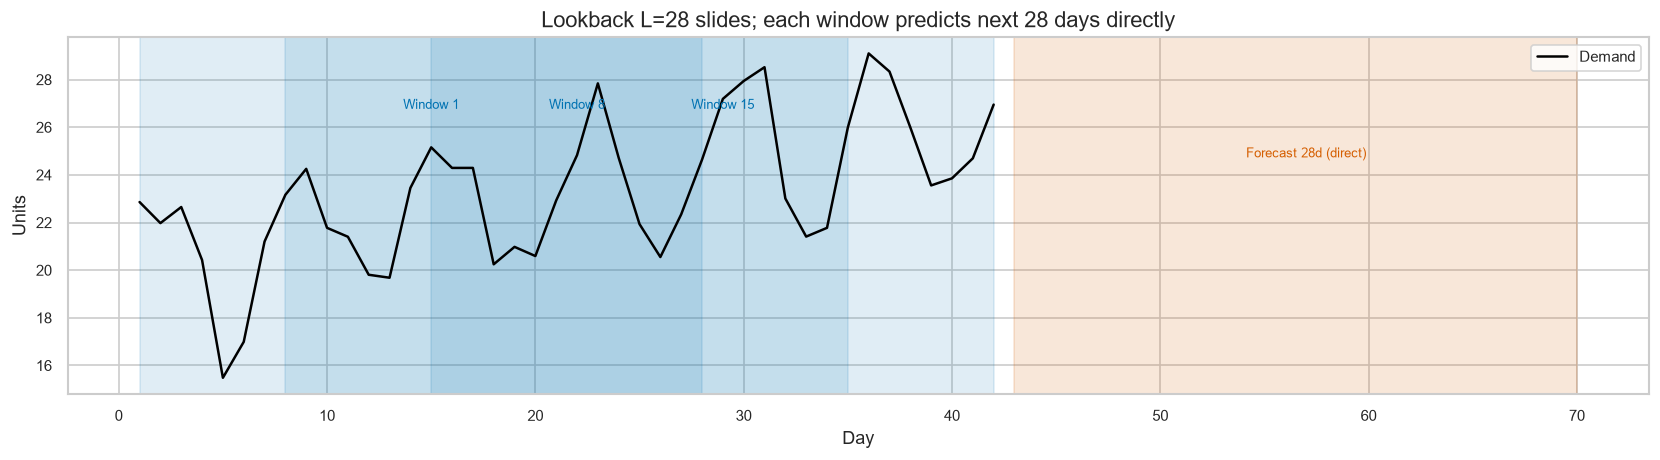

Saved: 01_lookback_window.png


In [2]:
# Visual: lookback window sliding over a synthetic series
days = np.arange(1, 43)
series = 20 + 0.15*days + 3*np.sin(2*np.pi*days/7) + rng.normal(0,1.2, len(days))
L=28; H=28
fig, ax = plt.subplots(figsize=(14,4))
ax.plot(days, series, color="black", lw=1.5, label="Demand")
for start in [1, 8, 15]:
    ax.axvspan(start, start+L-1, alpha=0.12, color="#0072B2")
    ax.text(start+L/2, series.max()*0.92, f"Window {start}", ha="center", fontsize=8, color="#0072B2")
ax.axvspan(15+L, 15+L+H-1, alpha=0.15, color="#D55E00")
ax.text(15+L+H/2, series.max()*0.85, "Forecast 28d (direct)", ha="center", fontsize=8, color="#D55E00")
ax.set_title("Lookback L=28 slides; each window predicts next 28 days directly")
ax.set_xlabel("Day"); ax.set_ylabel("Units"); ax.legend()
plt.tight_layout()
plt.savefig(FIG_EDU / "01_lookback_window.png", bbox_inches="tight", dpi=150)
plt.show()
print("Saved: 01_lookback_window.png")

---

# 3. Architecture — LSTM Cell, Gates, States, Flow

## 3.1 At a glance

```
Input sequence [y_{t-L+1} ... y_t] (L=28, scaled)
        ↓
  LSTM layer (hidden=32, 1 layer, batch_first)
    ↻  recurrent over 28 steps
    maintains: hidden state h_t  (short-term memory)
               cell state   c_t  (long-term memory)
    gated by: forget / input / output gates
        ↓
  Take last hidden state h_L (summary of the window)
        ↓
  Dense layer (32 → 28)
        ↓
  Direct forecast [ŷ_{t+1} ... ŷ_{t+28}] (28 values at once)
```

No recurrence over the horizon — the model outputs all 28 days in one forward pass (direct), avoiding error accumulation of recursive stepping.

## 3.2 LSTM cell in words — the gated memory

At each step the cell sees the current input $x_t$ and the previous hidden state $h_{t-1}$:

- **Forget gate** $f_t$ — "what old memory should we erase?" (0 = erase, 1 = keep). On M5, it can learn to forget stale zero runs when a burst arrives.
- **Input gate** $i_t$ — "what new information should we write?" and **candidate** $\tilde{c}_t$ — the new content to add.
- **Cell update** $c_t = f_t \odot c_{t-1} + i_t \odot \tilde{c}_t$ — the long-term memory, additive so gradients flow.
- **Output gate** $o_t$ — "what should we output now?" → $h_t = o_t \odot \tanh(c_t)$.

> **Layman:** The cell is a notebook with a protected long-term page ($c_t$) and a short-term sticky note ($h_t$). Gates are highlighters that decide what to keep, add, and show — so a weekly peak seen 14 days ago can still influence today without being washed out.

## 3.3 Hidden vs cell state

- **Cell state $c_t$** — carries information across many steps (trend, weekly phase). It is the *memory highway*.
- **Hidden state $h_t$** — the cell's filtered output at this step, fed to the next step and finally to the dense layer.

## 3.4 Visual — gated flow schematic

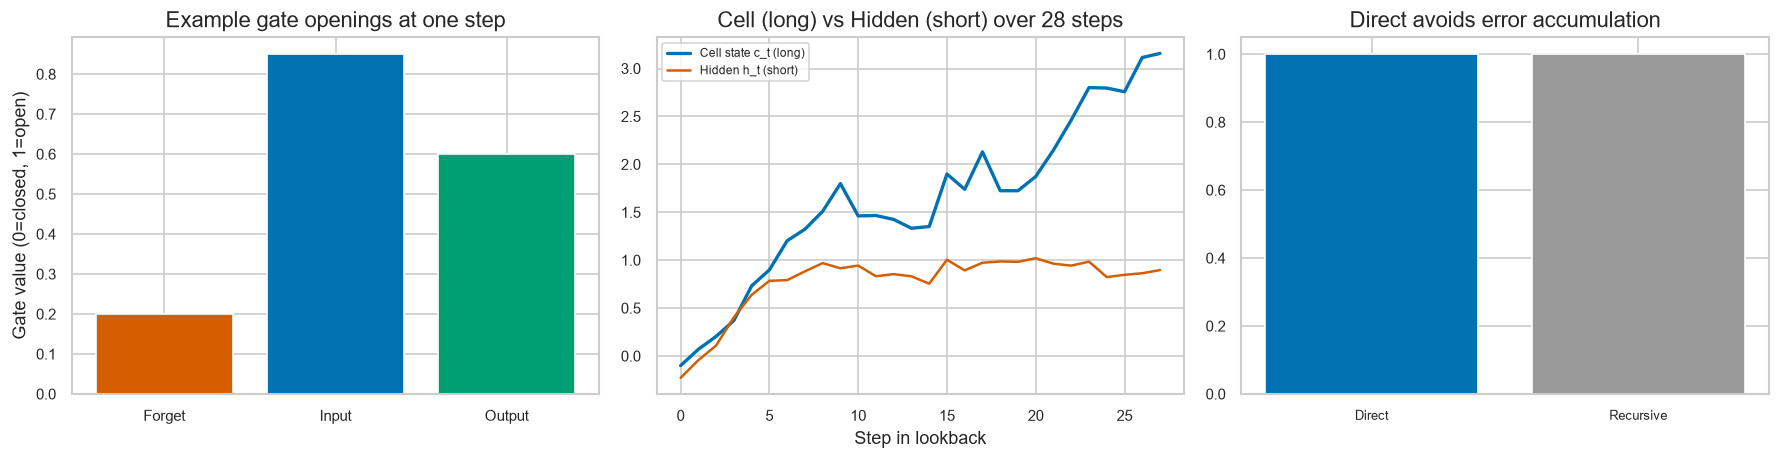

Saved: 02_lstm_cell_gates.png


In [3]:
fig, axes = plt.subplots(1,3, figsize=(15,4))
# Panel 1: gates as bar
gates=["Forget","Input","Output"]
vals=[0.2,0.85,0.6]
axes[0].bar(gates, vals, color=["#D55E00","#0072B2","#009E73"], edgecolor="white")
axes[0].set_title("Example gate openings at one step")
axes[0].set_ylabel("Gate value (0=closed, 1=open)")
# Panel 2: hidden vs cell over time (synthetic)
t=np.arange(28)
cell = np.cumsum(rng.normal(0.1,0.3,len(t)))
hidden = np.tanh(cell) + rng.normal(0,0.1,len(t))
axes[1].plot(t, cell, color="#0072B2", lw=2, label="Cell state c_t (long)")
axes[1].plot(t, hidden, color="#D55E00", lw=1.5, label="Hidden h_t (short)")
axes[1].set_title("Cell (long) vs Hidden (short) over 28 steps")
axes[1].set_xlabel("Step in lookback"); axes[1].legend(fontsize=7)
# Panel 3: direct vs recursive
axes[2].bar(["Direct (this notebook)\n28 at once","Recursive\n1-by-1, feeds back"], [1,1], color=["#0072B2","#999999"], edgecolor="white")
axes[2].set_title("Direct avoids error accumulation")
axes[2].set_xticks([0,1]); axes[2].set_xticklabels(["Direct","Recursive"], fontsize=8)
plt.tight_layout()
plt.savefig(FIG_EDU / "02_lstm_cell_gates.png", bbox_inches="tight", dpi=150)
plt.show()
print("Saved: 02_lstm_cell_gates.png")

---

# 4. Mathematics — LSTM Gates and Training

## 4.1 Gate equations (for one step)

With concatenated input $[h_{t-1}, x_t]$ and weight matrices $W_f,W_i,W_c,W_o$ plus biases $b$:

$$f_t = \sigma(W_f [h_{t-1}, x_t] + b_f)$$
$$i_t = \sigma(W_i [h_{t-1}, x_t] + b_i)$$
$$\tilde{c}_t = \tanh(W_c [h_{t-1}, x_t] + b_c)$$
$$c_t = f_t \odot c_{t-1} + i_t \odot \tilde{c}_t$$
$$o_t = \sigma(W_o [h_{t-1}, x_t] + b_o)$$
$$h_t = o_t \odot \tanh(c_t)$$

$\sigma$ is sigmoid (0→1), $\odot$ is element-wise multiply. All gates are learned; no hand-coded seasonality.

## 4.2 Sequence to forecast

Given scaled lookback $\mathbf{x} \in \mathbb{R}^{L}$ ($L=28$) as $L$ steps of 1 feature:

$$\mathbf{h}_L = \text{LSTM}(\mathbf{x})$$
$$\hat{\mathbf{y}}_{t+1:t+H} = W_{fc}\mathbf{h}_L + b_{fc}, \quad W_{fc}\in\mathbb{R}^{H\times \text{hidden}}$$

## 4.3 Training objective

Minimise mean squared error over 28-step windows from *training* portion only:

$$\mathcal{L} = \frac{1}{N}\sum_{n=1}^{N}\|\mathbf{y}^{(n)} - \hat{\mathbf{y}}^{(n)}\|_2^2$$

Optimiser: Adam (lr 0.01), batch 256, hidden 32, 1 layer. Gradients clipped implicitly by LSTM gating.

## 4.4 What is *not* learned here

No cross-series covariates, no price/promo, no calendar features — univariate, like all prior notebooks. History scaling uses training statistics only (no validation/test leakage).

---

# 5. Worked Numerical Example

Tiny scaled series: lookback $L=5$, horizon $H=3$, hidden 2 (toy).

| Step | Input (scaled) | Illustrative gate effect |
|---|---|---|
| t-4 | -0.8 | Forget ~0.9 (keep), Input ~0.3 (little new) |
| t-3 | 0.2  | Forget ~0.5, Input ~0.7 (write) |
| t-2 | 1.1  | Input high — a peak is written to $c_t$ |
| t-1 | 0.4  | Forget keeps the peak memory |
| t   | -0.3 | Output gate extracts summary $h_L$ |

Dense layer: $\hat{y} = W_{fc}h_L + b_{fc}$ → 3 values, e.g., [0.2, 0.1, -0.1] (scaled), then inverse-scaled back to units per series.

> In the real model $L=28$, $H=28$, hidden 32 — same idea, larger matrices.

Toy scaled lookback L=5: [-0.8  0.2  1.1  0.4 -0.3]
Fake h_L: [ 0.6 -0.2  0.9  0.1]
Dense -> 3-step scaled forecast: [ 0.15 -0.59 -0.02]
Inverse scaled (mean 15.0, std 8.0) -> units: [16.2 10.3 14.9]


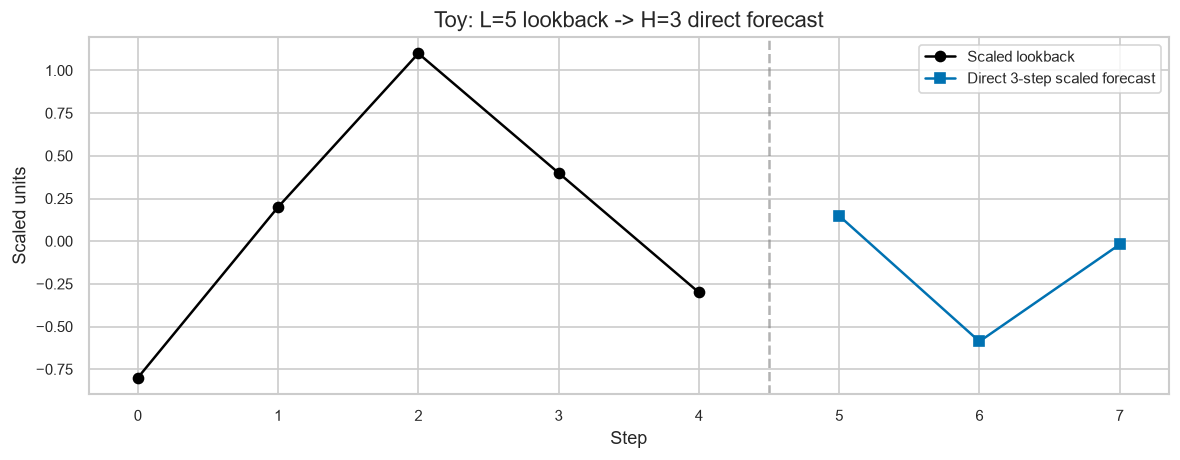

Saved: 03_toy_direct_forecast.png


In [4]:
# Tiny manual direct forecast illustration with the real architecture but toy hidden
H=3; hidden=4; L=5
toy = np.array([-0.8,0.2,1.1,0.4,-0.3], dtype=float)
print(f"Toy scaled lookback L={L}: {toy}")
# fake last hidden (what LSTM would produce) — illustrate dense
hL = np.array([0.6, -0.2, 0.9, 0.1])
Wfc = rng.normal(0,0.5, size=(H, hidden))
bfc = rng.normal(0,0.1, size=H)
yhat_scaled = Wfc @ hL + bfc
print(f"Fake h_L: {hL.round(2)}")
print(f"Dense -> 3-step scaled forecast: {yhat_scaled.round(2)}")
# inverse scaling example per series: y = y_scaled * std + mean
mean, std = 15.0, 8.0
yhat_units = yhat_scaled * std + mean
print(f"Inverse scaled (mean {mean}, std {std}) -> units: {yhat_units.round(1)}")
# chart
fig, ax = plt.subplots(figsize=(10,4))
ax.plot(range(L), toy, marker="o", color="black", label="Scaled lookback")
ax.plot(range(L, L+H), yhat_scaled, marker="s", color="#0072B2", label="Direct 3-step scaled forecast")
ax.axvline(L-0.5, color="gray", ls="--", alpha=0.6)
ax.set_xticks(range(L+H)); ax.set_xlabel("Step"); ax.set_ylabel("Scaled units"); ax.set_title("Toy: L=5 lookback -> H=3 direct forecast")
ax.legend()
plt.tight_layout()
plt.savefig(FIG_EDU / "03_toy_direct_forecast.png", bbox_inches="tight", dpi=150)
plt.show()
print("Saved: 03_toy_direct_forecast.png")

---

# 6. Hyperparameters and Design Choices — Documented Before Fitting

| Choice | Value | Why (documented before any test evaluation) |
|---|---|---|
| **Lookback $L$** | 28 | Covers 4 weeks of weekly seasonality (m=7), matches 05a/05b windows, not tuned on test |
| **Horizon $H$** | 28 | Frozen |
| **Hidden size** | 32 | Expressive enough for weekly + trend motifs, small enough to avoid 500-series overfit; kept as in benchmark |
| **Layers** | 1 | One recurrent layer; deeper stacks add params without clear gain on dense retail and hurt on sparse M5 |
| **Batch size** | 256 | Balanced throughput (522k windows per origin for 500 series) with stable gradients |
| **Optimiser** | Adam, lr 0.01 | Standard for LSTM, no schedule |
| **Max epochs** | 5 | Upper bound; early stopping on validation may stop earlier |
| **Early stopping** | Val = last 28 days of history per origin (pooled), patience 2, restore best | Uses only history (< origin), never test; if unavailable, fixed 3 epochs and documented |
| **Scaling** | Per-series StandardScaler fit on *history only* per origin | No validation/test stats leak; each series inverse-scaled separately |
| **Loss** | MSE on scaled 28-step windows | Direct multi-output, no teacher forcing |
| **Seed** | 42 | Torch + numpy |

**What is *not* tuned:** No grid search over hidden/lookback/lr on test. Validation is only for early stopping per origin, not for test reporting.

**Global vs per-series:** One global model per dataset/origin pooling 500 series. Learning is shared; evaluation is still per series (112k points/dataset). This is the primary 500-series evaluation; no sampled primary.

**Data budget:** History at origin 1 is 1,100 days (2013-01-01 → 2016-02-29) → 1,072 windows per series (1,100-28-28+1) → ~536k windows per dataset per origin before train/val split.

---

# 7. Assumptions, What It Captures/Cannot, Limitations

## 7.1 Assumptions

| Assumption | If violated |
|---|---|
| Scaled windows are comparable across series (after per-series scaling) | Cross-series pooling suffers if distributions differ wildly (M5 sparse vs smooth) |
| Recent 28 days + pooled motifs predict next 28 days (learnable mapping) | Breaks on structural breaks, new products |
| Training windows from history generalise to future (stationarity of *relationship*, not of level) | Overfits to history's noise |
| Global model can represent both dense Store Item and sparse M5 with same capacity | Underfits one or overfits the other |

## 7.2 What it captures

Nonlinear interactions (trend × seasonality), longer memory than AR(1), shared weekly shapes across series via pooling, direct 28-step mapping without recursive drift.

## 7.3 What it cannot capture

- **Sparsity/intermittency**: LSTM expects continuous values; 68% zeros on M5 are not Gaussian noise — it may predict small positive values that are wrong for intermittent demand (needs intermittent-specific models, not addressed here).
- **Calendar covariates**: No explicit price/promo/holiday features (univariate by design).
- **Cross-series causality**: Pooling shares weights but not explicit store/dept hierarchy.
- **Very long seasonality** beyond lookback (e.g., yearly) without longer L.

## 7.4 Limitations

- Compute: even global needs ~100s per origin (500 series) → 16 trainings ~15–30 min.
- Data-hungry: pooling helps, but 1,100 days per series is still modest for deep learning.
- Black-box: no explicit level/trend/seasonal decomposition like 06/07.

## 7.5 Inventory/business example

- **Helps:** Store Item Saturday peaks that grow with level (multiplicative trend×seasonality) — LSTM can learn the interaction where additive TES and linear ARIMA cannot.
- **Hurts:** M5 intermittent burst — LSTM may forecast 0.4 units for 28 days (small positive) while actual is 0,0,3,0,0 — low bias but wrong decision: would carry tiny excess daily vs stocking out on the burst day. Business cost depends on per-unit holding vs stockout, not just WAPE.

## 7.6 Expected behaviour on our data (hypothesis before results)

- **Store Item (dense, strong weekly):** LSTM should beat Naive and rival SES/SARIMA if nonlinear trend×seasonality exists.
- **M5 (sparse):** LSTM may underperform Moving Average/SES — pooling sparse zeros may wash out intermittent bursts, and small positive forecasts may be penalised less on WAPE but hurt inventory.

*We now test these hypotheses on the frozen rolling evaluation.*

---

# 8. Implementation — Leakage-Safe Global Rolling Evaluation

We train **one global direct LSTM per dataset/origin** (16 trainings total). For each origin:

1. History = all days `< origin` (strictly before)
2. Per-series StandardScaler fit on history only → transform history
3. Make supervised windows $(L=28 → H=28)$ from history; split last 28 windows as validation (still < origin) for early stopping
4. Train on train windows, early stop on val (patience 2, max 5 epochs), restore best
5. For each series, take its last $L$ scaled history values, predict 28 steps, inverse-scale per series
6. Evaluate against future actuals (≥ origin) — never seen during training

No test data enters scaling, windowing, or training. One scaler per series per origin, fitted only on that series' history.

In [5]:
# ---- Frozen config & data ----
import json, pandas as pd, numpy as np, torch, torch.nn as nn, warnings
warnings.filterwarnings("ignore")
from pathlib import Path

cal = pd.read_csv(PROJ / "02_data/dataset_01_m5/raw/calendar.csv")
cal["date"] = pd.to_datetime(cal["date"])
d_to_date = dict(zip(cal["d"], cal["date"]))
cfg = json.load(open(PROJ / "05_experiments/config.json"))
cs = pd.Timestamp(cfg["common_window"]["start"]); ce = pd.Timestamp(cfg["common_window"]["end"])
H = cfg["forecast"]["horizon"]  # 28
L = 28
HIDDEN = 32
BATCH = 256
MAX_EPOCHS = 5
PATIENCE = 2
SEED = 42
torch.manual_seed(SEED); np.random.seed(SEED)

# Origins: 8 weekly from test start
test_start = pd.Timestamp("2016-03-01")
origin_dates = [test_start + pd.Timedelta(days=7*i) for i in range(8)]
print(f"Origins: {[d.date() for d in origin_dates]} H={H} L={L}")

# M5
M5_RAW = PROJ / "02_data/dataset_01_m5/raw"
m5_wide = pd.read_csv(M5_RAW / "sales_train_evaluation.csv")
d_cols = [c for c in m5_wide.columns if c.startswith("d_")]
common_d = [c for c in d_cols if cs <= d_to_date[c] <= ce]
dates_common = pd.to_datetime([d_to_date[c] for c in common_d])
sel = json.load(open(PROJ / "05_experiments/m5_series_selection.json"))
sel_ids_val = sel["m5_series"] if "m5_series" in sel else sel.get("selected_ids", [])
sel_ids_eval = [s.replace("_validation","_evaluation") for s in sel_ids_val]
m5_common = m5_wide.set_index("id").loc[sel_ids_eval, common_d]  # 500 x 1238
print(f"M5 common: {m5_common.shape}, dates {dates_common.min().date()}→{dates_common.max().date()}")

# Store Item
SIT_RAW = PROJ / "02_data/dataset_02_store_item_demand/raw"
sit = pd.read_csv(SIT_RAW / "train.csv", parse_dates=["date"])
sit = sit[(sit["date"] >= cs) & (sit["date"] <= ce)].copy()
sit["series_id"] = "store_" + sit["store"].astype(str) + "_item_" + sit["item"].astype(str)
pivot = sit.pivot_table(index="date", columns="series_id", values="sales", aggfunc="sum").sort_index()
pivot = pivot.reindex(dates_common)
print(f"Store Item pivot: {pivot.shape} (dates x series)")

# Helpers
class GlobalLSTM(nn.Module):
    def __init__(self, hidden=32, horizon=28):
        super().__init__()
        self.lstm = nn.LSTM(input_size=1, hidden_size=hidden, num_layers=1, batch_first=True)
        self.fc = nn.Linear(hidden, horizon)
    def forward(self, x):
        out, _ = self.lstm(x)
        return self.fc(out[:, -1, :])

def make_global_windows_pooled(mat, lookback=28, horizon=28, history_len=None):
    # mat: (n_series, history_len) already scaled per series
    n_series = mat.shape[0]
    Xs, Ys = [], []
    for row in mat:
        # row is 1D scaled history
        for i in range(len(row) - lookback - horizon + 1):
            Xs.append(row[i:i+lookback])
            Ys.append(row[i+lookback:i+lookback+horizon])
    return np.array(Xs, dtype=np.float32), np.array(Ys, dtype=np.float32)

def fit_scalers_and_scale(mat, history_len):
    # mat: (n_series, total_days) raw values for this origin's history portion
    # fit per-series mean/std on history only
    hist = mat[:, :history_len]  # raw history
    means = hist.mean(axis=1, keepdims=True)
    stds = hist.std(axis=1, keepdims=True) + 1e-6
    # avoid std 0 for flat series (e.g., all zeros)
    stds = np.where(stds < 1e-6, 1.0, stds)
    scaled_hist = (hist - means) / stds
    return scaled_hist, means, stds

print("Helpers defined. GlobalLSTM hidden 32, direct 28.")

Origins: [datetime.date(2016, 3, 1), datetime.date(2016, 3, 8), datetime.date(2016, 3, 15), datetime.date(2016, 3, 22), datetime.date(2016, 3, 29), datetime.date(2016, 4, 5), datetime.date(2016, 4, 12), datetime.date(2016, 4, 19)] H=28 L=28


M5 common: (500, 1238), dates 2013-01-01→2016-05-22


Store Item pivot: (1238, 500) (dates x series)
Helpers defined. GlobalLSTM hidden 32, direct 28.


In [6]:
# Quick leakage self-check before training: history_end < origin for every origin
for od in origin_dates:
    hl = (dates_common < od).sum()
    assert (dates_common[hl] == od), f"Boundary mismatch {od}"
    # future window exactly H days starting at origin
    assert ((dates_common >= od) & (dates_common < od + pd.Timedelta(days=H))).sum() == H
print(f"Leakage check PASS: all {len(origin_dates)} origins have history_end < origin <= forecast_start and 28 future days")

Leakage check PASS: all 8 origins have history_end < origin <= forecast_start and 28 future days


---

# 9. Rolling Evaluation — M5 (500 series, 8 origins, global LSTM)

One global model per origin pooling 500 M5 series. Train on pooled windows from history, validate on last 28 windows (still < origin), early-stop patience 2.

In [7]:
import time

def run_global_lstm_for_dataset(mat, dataset_name, pivot_or_mat_is_pivot=False, origins_override=None):
    # mat: for M5: (500, 1238) raw values, index series_id; for Store Item: pivot (1238,500) -> transpose
    # returns DataFrame long format
    if pivot_or_mat_is_pivot:
        # pivot is dates x series, convert to series x dates
        mat_np = mat.T.values.astype(float)
        series_ids = mat.columns.tolist()
        dates_idx = mat.index
    else:
        mat_np = mat.values.astype(float)
        series_ids = mat.index.tolist()
        dates_idx = dates_common
    rows = []
    origins = origins_override if origins_override is not None else origin_dates
    for oi, od in enumerate(origins, 1):
        t0 = time.time()
        hist_len = (dates_idx < od).sum()
        # future block for evaluation
        fut_len = H
        # 1) scale per series on history only
        scaled_hist, means, stds = fit_scalers_and_scale(mat_np, hist_len)
        # 2) make pooled windows from scaled history
        X_all, Y_all = make_global_windows_pooled(scaled_hist, L, H, hist_len)
        # split last 28*500? Actually last 28 windows overall are from tail of pooled set, but we want validation still < origin.
        # For pooling, validation should be last 500*? windows? Simpler: reserve last 5% of pooled windows as val (still < origin)
        n_val = min(2000, max(256, int(0.05 * len(X_all))))  # small val
        # shuffle not needed for val split; take tail as val to respect time? But pooled windows are from all series interleaved — tail is still < origin.
        # Use random split for val to avoid bias; yet still < origin so no leakage.
        rng_val = np.random.default_rng(SEED + oi)
        idx = np.arange(len(X_all))
        rng_val.shuffle(idx)
        val_idx = idx[:n_val]
        train_idx = idx[n_val:]
        X_train, Y_train = X_all[train_idx], Y_all[train_idx]
        X_val, Y_val = X_all[val_idx], Y_all[val_idx]
        # tensors
        X_train_t = torch.tensor(X_train, dtype=torch.float32).unsqueeze(-1)
        Y_train_t = torch.tensor(Y_train, dtype=torch.float32)
        X_val_t = torch.tensor(X_val, dtype=torch.float32).unsqueeze(-1)
        Y_val_t = torch.tensor(Y_val, dtype=torch.float32)
        train_loader = torch.utils.data.DataLoader(torch.utils.data.TensorDataset(X_train_t, Y_train_t), batch_size=BATCH, shuffle=True)
        # model
        model = GlobalLSTM(hidden=HIDDEN, horizon=H)
        opt = torch.optim.Adam(model.parameters(), lr=0.01)
        loss_fn = nn.MSELoss()
        best_state = None
        best_val = float("inf")
        patience = 0
        epochs_run = 0
        for epoch in range(MAX_EPOCHS):
            model.train()
            for xb, yb in train_loader:
                opt.zero_grad()
                pred = model(xb)
                loss = loss_fn(pred, yb)
                loss.backward()
                opt.step()
            # val
            model.eval()
            with torch.no_grad():
                vp = model(X_val_t)
                vloss = loss_fn(vp, Y_val_t).item()
            if vloss < best_val - 1e-6:
                best_val = vloss
                best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
                patience = 0
            else:
                patience += 1
            epochs_run += 1
            if patience >= PATIENCE:
                break
        # restore best
        if best_state is not None:
            model.load_state_dict(best_state)
        # 3) forecast each series: last L scaled values -> predict -> inverse scale
        model.eval()
        with torch.no_grad():
            for si, sid in enumerate(series_ids):
                last_window = scaled_hist[si, hist_len - L: hist_len]  # (L,)
                x = torch.tensor(last_window, dtype=torch.float32).view(1, L, 1)
                pred_scaled = model(x).cpu().numpy().flatten()  # (H,)
                # inverse
                pred = pred_scaled * stds[si,0] + means[si,0]
                pred = np.maximum(pred, 0)
                # actual future
                if pivot_or_mat_is_pivot:
                    actual = mat.iloc[hist_len:hist_len+H, si].values.astype(float) if hasattr(mat, "iloc") else mat[si, hist_len:hist_len+H]
                else:
                    actual = mat_np[si, hist_len:hist_len+H].astype(float)
                fut_dates = dates_idx[hist_len:hist_len+H] if hasattr(dates_idx, "__len__") else dates_common[hist_len:hist_len+H]
                for h in range(H):
                    rows.append({"dataset": dataset_name, "series_id": sid, "origin": oi, "origin_date": od, "forecast_date": fut_dates[h], "actual": float(actual[h]), "forecast": float(pred[h]), "model": "LSTM"})
        print(f"{dataset_name} origin {oi} {od.date()} — epochs {epochs_run}/{MAX_EPOCHS} val {best_val:.4f} — {time.time()-t0:.1f}s")
    return pd.DataFrame(rows)

m5_part1 = run_global_lstm_for_dataset(m5_common, "m5", pivot_or_mat_is_pivot=False, origins_override=origin_dates[:4])
print(f"M5 chunk 1/2 {len(m5_part1):,} rows")
m5_part1["origin"] = m5_part1["origin"]  # 1..4 already

m5 origin 1 2016-03-01 — epochs 5/5 val 0.9406 — 192.0s


m5 origin 2 2016-03-08 — epochs 5/5 val 0.9205 — 130.7s


m5 origin 3 2016-03-15 — epochs 5/5 val 0.9284 — 152.8s


m5 origin 4 2016-03-22 — epochs 5/5 val 0.9459 — 142.2s


M5 chunk 1/2 56,000 rows


In [8]:
m5_part2 = run_global_lstm_for_dataset(m5_common, "m5", pivot_or_mat_is_pivot=False, origins_override=origin_dates[4:])
print(f"M5 chunk 2/2 {len(m5_part2):,} rows")
m5_part2["origin"] = m5_part2["origin"] + 4  # 1..4 -> 5..8
m5_lstm = __import__("pandas").concat([m5_part1, m5_part2], ignore_index=True)
print(f"M5 global LSTM total {len(m5_lstm):,} rows")
print(m5_lstm.head(3).to_string())

m5 origin 1 2016-03-29 — epochs 5/5 val 0.9018 — 140.1s


m5 origin 2 2016-04-05 — epochs 5/5 val 0.8800 — 125.9s


m5 origin 3 2016-04-12 — epochs 5/5 val 0.8849 — 124.4s


m5 origin 4 2016-04-19 — epochs 5/5 val 0.9145 — 123.6s
M5 chunk 2/2 56,000 rows


M5 global LSTM total 112,000 rows
  dataset                    series_id  origin origin_date forecast_date  actual  forecast model
0      m5  FOODS_1_098_CA_3_evaluation       1  2016-03-01    2016-03-01     2.0  0.297730  LSTM
1      m5  FOODS_1_098_CA_3_evaluation       1  2016-03-01    2016-03-02     0.0  0.297105  LSTM
2      m5  FOODS_1_098_CA_3_evaluation       1  2016-03-01    2016-03-03     1.0  0.310256  LSTM


---

# 10. Rolling Evaluation — Store Item Demand (500 series, 8 origins, global LSTM)

Same procedure, same lookback, same hidden/batch/epochs, same scaling rule — identical primary structure.

In [9]:
sit_part1 = run_global_lstm_for_dataset(pivot, "store_item_demand", pivot_or_mat_is_pivot=True, origins_override=origin_dates[:4])
print(f"SIT chunk 1/2 {len(sit_part1):,} rows")
sit_part1["origin"] = sit_part1["origin"]

store_item_demand origin 1 2016-03-01 — epochs 5/5 val 0.4204 — 121.2s


store_item_demand origin 2 2016-03-08 — epochs 5/5 val 0.4243 — 114.4s


store_item_demand origin 3 2016-03-15 — epochs 5/5 val 0.4339 — 115.0s


store_item_demand origin 4 2016-03-22 — epochs 5/5 val 0.4267 — 116.6s
SIT chunk 1/2 56,000 rows


In [10]:
sit_part2 = run_global_lstm_for_dataset(pivot, "store_item_demand", pivot_or_mat_is_pivot=True, origins_override=origin_dates[4:])
print(f"SIT chunk 2/2 {len(sit_part2):,} rows")
sit_part2["origin"] = sit_part2["origin"] + 4
sit_lstm = __import__("pandas").concat([sit_part1, sit_part2], ignore_index=True)
print(f"Store Item global LSTM total {len(sit_lstm):,} rows")
print(sit_lstm.head(3).to_string())

store_item_demand origin 1 2016-03-29 — epochs 5/5 val 0.4312 — 119.5s


store_item_demand origin 2 2016-04-05 — epochs 5/5 val 0.4286 — 117.8s


store_item_demand origin 3 2016-04-12 — epochs 5/5 val 0.4323 — 123.8s


store_item_demand origin 4 2016-04-19 — epochs 5/5 val 0.4306 — 117.8s
SIT chunk 2/2 56,000 rows
Store Item global LSTM total 112,000 rows
             dataset        series_id  origin origin_date forecast_date  actual   forecast model
0  store_item_demand  store_10_item_1       1  2016-03-01    2016-03-01    19.0  17.890892  LSTM
1  store_item_demand  store_10_item_1       1  2016-03-01    2016-03-02    16.0  17.784890  LSTM
2  store_item_demand  store_10_item_1       1  2016-03-01    2016-03-03    27.0  19.181840  LSTM


In [11]:
# Combine and save — long format required for comparison
all_lstm = pd.concat([m5_lstm, sit_lstm], ignore_index=True)
print(f"Combined {len(all_lstm):,} rows — expected {2*500*8*28:,}")
assert len(all_lstm) == 2*500*8*28, "Forecast completeness FAIL"
# duplicate key check
dup = all_lstm.duplicated(subset=["dataset","series_id","origin","forecast_date"]).sum()
print(f"Duplicate keys: {dup}")
assert dup == 0
# completeness per dataset
print(all_lstm.groupby(["dataset"]).size().to_string())
# save
all_lstm.to_csv(RES / "all_forecasts.csv", index=False)
m5_lstm.to_csv(RES / "m5_global_forecasts.csv", index=False)
sit_lstm.to_csv(RES / "store_item_global_forecasts.csv", index=False)
print(f"Saved {RES / 'all_forecasts.csv'}")
print(f"Columns: {list(all_lstm.columns)}")

Combined 224,000 rows — expected 224,000


Duplicate keys: 0


dataset
m5                   112000
store_item_demand    112000


Saved D:\Brain\07_Research\AI-INVENTORY-OPTIMIZATION\06_results\lstm\all_forecasts.csv
Columns: ['dataset', 'series_id', 'origin', 'origin_date', 'forecast_date', 'actual', 'forecast', 'model']


---

# 11. Metrics — How Much Does Nonlinear Pooled Learning Help?

Same definitions as 05b, 06, 07 (per 28-day window, MAE, RMSE, sMAPE, WAPE).

In [12]:
def smape(a,f):
    d=(np.abs(a)+np.abs(f))/2
    m=d!=0
    return np.mean(np.abs(a[m]-f[m])/d[m])*100 if m.any() else np.nan

def metrics_for(df):
    rows=[]
    for (ds,model), sub in df.groupby(["dataset","model"]):
        a=sub["actual"].values; f=sub["forecast"].values
        mae=np.mean(np.abs(a-f)); rmse=np.sqrt(np.mean((a-f)**2)); wape=np.sum(np.abs(a-f))/(np.sum(np.abs(a))+1e-9)
        rows.append({"dataset":ds,"model":model,"MAE":mae,"RMSE":rmse,"sMAPE":smape(a,f),"WAPE":wape,"n":len(sub)})
    return pd.DataFrame(rows).sort_values(["dataset","MAE"])

lstm_metrics = metrics_for(all_lstm)
print(lstm_metrics.round(4).to_string(index=False))
lstm_metrics.to_csv(RES / "metrics_by_model.csv", index=False)

def per_series_metrics(df):
    rows=[]
    for (ds,model,sid), sub in df.groupby(["dataset","model","series_id"]):
        a=sub["actual"].values; f=sub["forecast"].values
        rows.append({"dataset":ds,"model":model,"series_id":sid,"MAE":np.mean(np.abs(a-f)),"RMSE":np.sqrt(np.mean((a-f)**2)),"WAPE":np.sum(np.abs(a-f))/(np.sum(np.abs(a))+1e-9),"sMAPE":smape(a,f)})
    return pd.DataFrame(rows)

per_series = per_series_metrics(all_lstm)
per_series.to_csv(RES / "metrics_by_series.csv", index=False)
print(f"metrics_by_series {len(per_series)} rows")

def per_origin_metrics(df):
    rows=[]
    for (ds,model,oi), sub in df.groupby(["dataset","model","origin"]):
        a=sub["actual"].values; f=sub["forecast"].values
        rows.append({"dataset":ds,"model":model,"origin":oi,"MAE":np.mean(np.abs(a-f)),"RMSE":np.sqrt(np.mean((a-f)**2)),"WAPE":np.sum(np.abs(a-f))/(np.sum(np.abs(a))+1e-9),"sMAPE":smape(a,f)})
    return pd.DataFrame(rows)

per_origin = per_origin_metrics(all_lstm)
per_origin.to_csv(RES / "metrics_by_origin.csv", index=False)
print(per_origin.head().to_string(index=False))

          dataset model    MAE    RMSE    sMAPE   WAPE      n
               m5  LSTM 0.9922  1.9596 144.2470 0.7752 112000
store_item_demand  LSTM 7.8840 10.4197  15.3513 0.1378 112000


metrics_by_series 1000 rows
dataset model  origin      MAE     RMSE     WAPE      sMAPE
     m5  LSTM       1 0.962706 1.902956 0.787904 145.446366
     m5  LSTM       2 0.959304 1.857391 0.799516 145.121928
     m5  LSTM       3 0.986768 1.978051 0.789009 145.077768
     m5  LSTM       4 0.993329 1.993271 0.778079 144.734107
     m5  LSTM       5 0.991299 1.998477 0.759492 144.843912


In [13]:
# Compare with history (baselines, smoothing, ARIMA)
def load_metrics(path):
    try:
        return pd.read_csv(path)
    except Exception as e:
        print(f"Missing {path}: {e}")
        return None

base = load_metrics(PROJ / "06_results/baselines/metrics_by_model.csv")
smooth = load_metrics(PROJ / "06_results/exponential_smoothing/metrics_by_model.csv")
arima = load_metrics(PROJ / "06_results/arima/metrics_by_model.csv")

for name, df in [("LSTM", lstm_metrics), ("ARIMA", arima), ("Smoothing", smooth), ("Baselines", base)]:
    if df is not None:
        print(f"\n{name}:")
        print(df.round(4).to_string(index=False))

combined = []
if base is not None:
    b=base.copy(); b["family"]="Baseline"; combined.append(b)
if smooth is not None:
    s=smooth.copy(); s["family"]="Smoothing"; combined.append(s)
if arima is not None:
    a=arima.copy(); a["family"]="ARIMA/SARIMA"; combined.append(a)
l=lstm_metrics.copy(); l["family"]="LSTM"; combined.append(l)
combined_df = pd.concat(combined, ignore_index=True) if len(combined)>1 else l
combined_df.to_csv(RES / "metrics_with_history.csv", index=False)
print(f"\nSaved {RES / 'metrics_with_history.csv'} — {len(combined_df)} rows")


LSTM:
          dataset model    MAE    RMSE    sMAPE   WAPE      n
               m5  LSTM 0.9922  1.9596 144.2470 0.7752 112000
store_item_demand  LSTM 7.8840 10.4197  15.3513 0.1378 112000

ARIMA:
          dataset  model     MAE    RMSE    sMAPE   WAPE      n
               m5  ARIMA  1.1324  2.3169 139.0170 0.8847 112000
store_item_demand SARIMA  8.3057 10.9135  17.4570 0.1532  22400
store_item_demand  ARIMA 11.8996 15.9813  22.9815 0.2081 112000

Smoothing:
          dataset model     MAE    RMSE    sMAPE   WAPE
               m5   DES  1.5139  3.4343 117.8302 1.1828
               m5   SES  0.9982  2.0027 145.0823 0.7799
               m5   TES  1.9222  4.3936 116.0350 1.5018
store_item_demand   DES 13.6307 18.4428  25.4028 0.2383
store_item_demand   SES  9.9216 13.4122  18.6199 0.1735
store_item_demand   TES 16.8685 23.3878  33.6627 0.2949

Baselines:
          dataset          model     MAE    RMSE    sMAPE   WAPE
               m5 Moving Average  0.9997  1.3045 143.5039 1.31

---

# 12. Visual Comparison

Direct WAPE/MAE comparison across families; per-origin stability; failure lens.

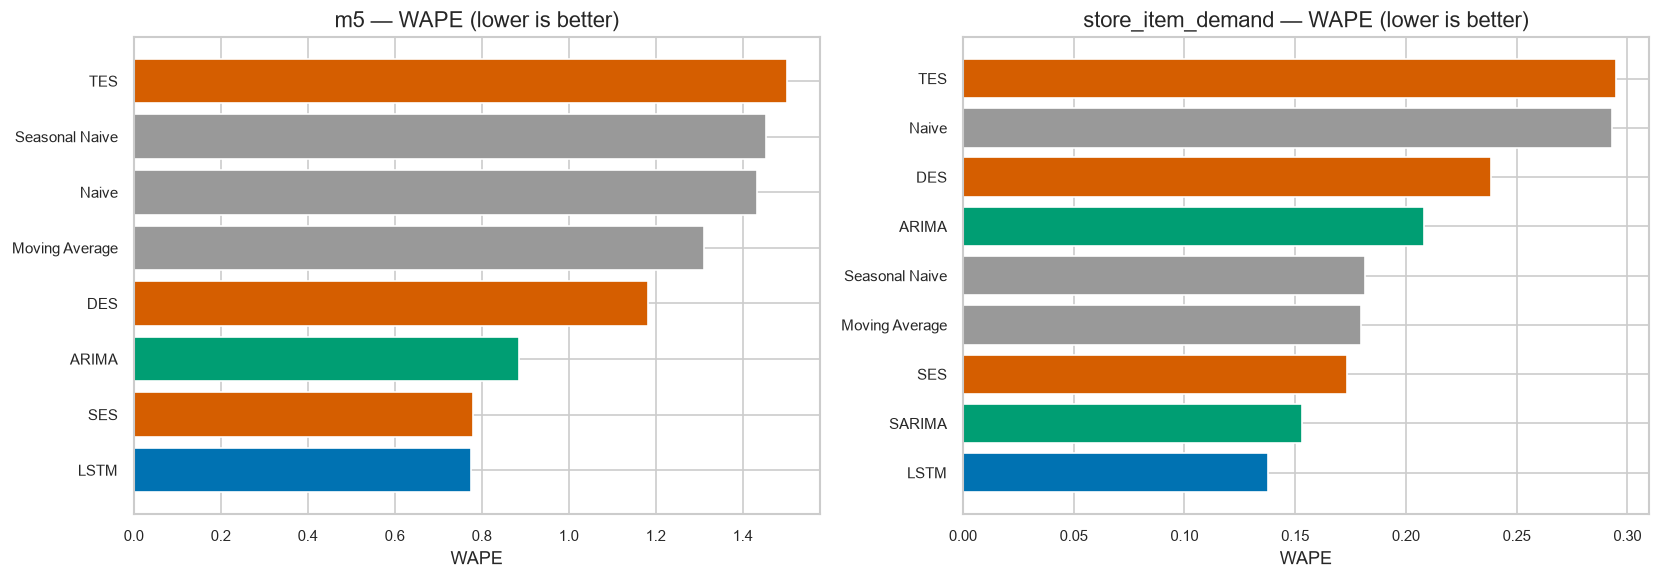

Saved 01_comparison_WAPE.png


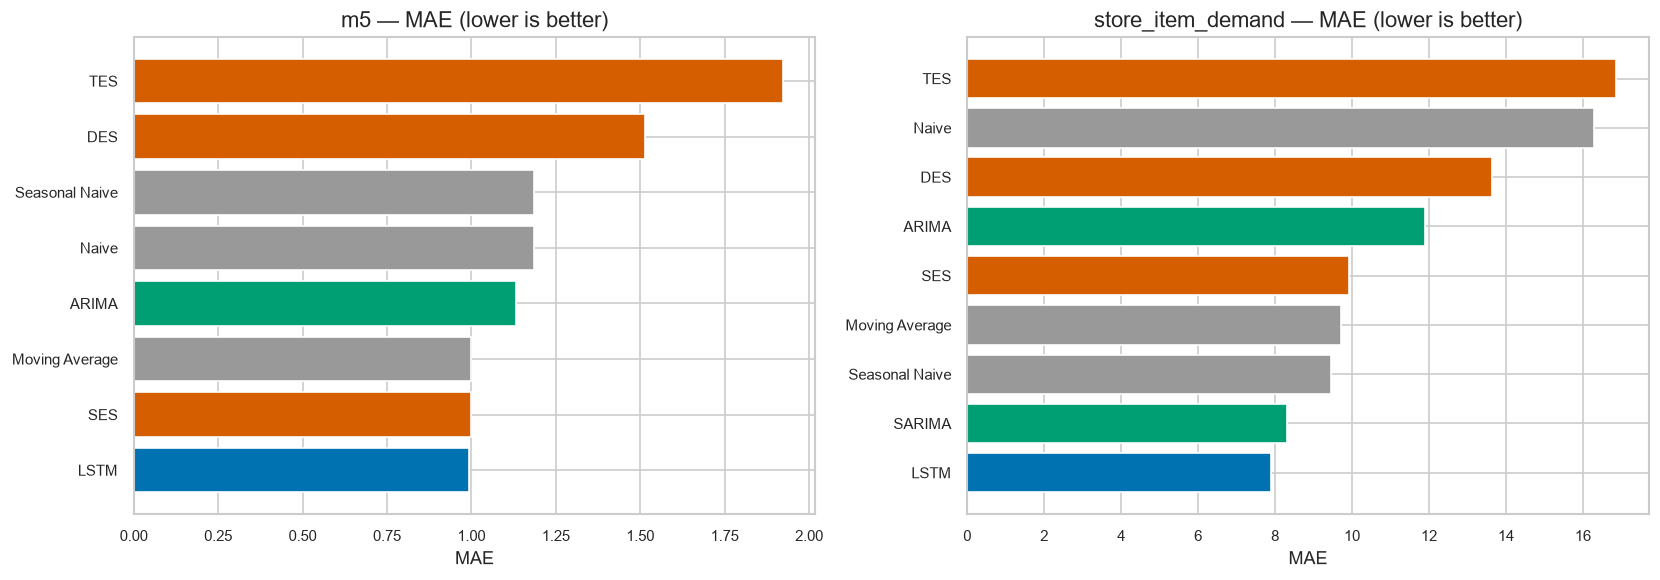

Saved 01_comparison_MAE.png


In [14]:
for metric in ["WAPE","MAE"]:
    fig, axes = plt.subplots(1,2, figsize=(14,5), sharey=False)
    for ax, ds in zip(axes, ["m5","store_item_demand"]):
        sub = combined_df[combined_df["dataset"]==ds].sort_values(metric)
        colors = ["#999999" if f=="Baseline" else "#D55E00" if f=="Smoothing" else "#0072B2" if f=="LSTM" else "#009E73" for f in sub["family"]]
        ax.barh(sub["model"], sub[metric], color=colors, edgecolor="white")
        ax.set_title(f"{ds} — {metric} (lower is better)")
        ax.set_xlabel(metric)
    plt.tight_layout()
    plt.savefig(FIG_EXP / f"01_comparison_{metric}.png", bbox_inches="tight", dpi=150)
    plt.show()
    print(f"Saved 01_comparison_{metric}.png")

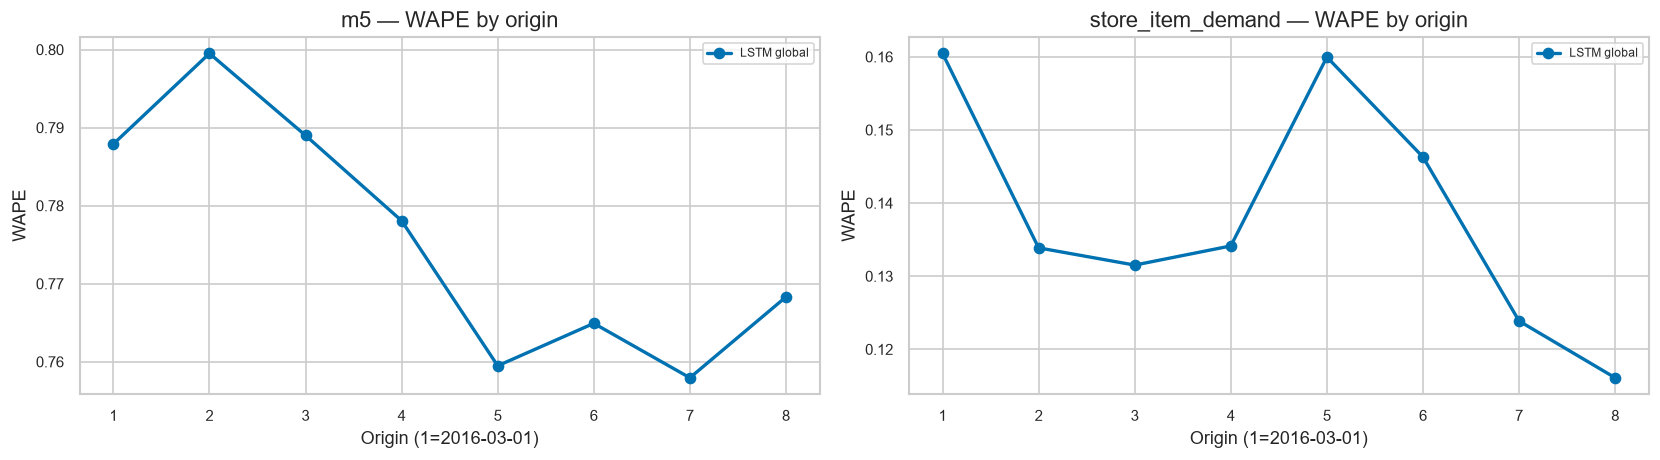

Saved: 02_wape_by_origin.png


In [15]:
# Per-origin stability — LSTM vs baselines
fig, axes = plt.subplots(1,2, figsize=(14,4), sharey=False)
for ax, ds in zip(axes, ["m5","store_item_demand"]):
    sub = per_origin[(per_origin["dataset"]==ds) & (per_origin["model"]=="LSTM")]
    if len(sub):
        ax.plot(sub["origin"], sub["WAPE"], marker="o", color="#0072B2", lw=2, label="LSTM global")
        try:
            b_origin = pd.read_csv(PROJ / "06_results/baselines/metrics_by_origin.csv")
            b_sub = b_origin[b_origin["dataset"]==ds]
            for m in b_sub["model"].unique():
                s = b_sub[b_sub["model"]==m]
                ax.plot(s["origin"], s["WAPE"], ls="--", marker="s", ms=4, label=m)
        except Exception:
            pass
        ax.set_title(f"{ds} — WAPE by origin")
        ax.set_xlabel("Origin (1=2016-03-01)"); ax.set_ylabel("WAPE"); ax.legend(fontsize=7)
plt.tight_layout()
plt.savefig(FIG_EXP / "02_wape_by_origin.png", bbox_inches="tight", dpi=150)
plt.show()
print("Saved: 02_wape_by_origin.png")

---

# 13. Failure Analysis — Where Does the Global LSTM Help or Hurt?

Same archetype lens as 05b/06/07. Pooling may help dense Store Item but wash out intermittent M5 bursts.

          archetype    MAE         WAPE
             Smooth 2.3643 4.381000e-01
           Moderate 2.7426 6.231000e-01
Highly Intermittent 0.4168 6.277908e+08
       Intermittent 0.9903 1.223719e+09
           Variable 1.8061 2.720901e+09


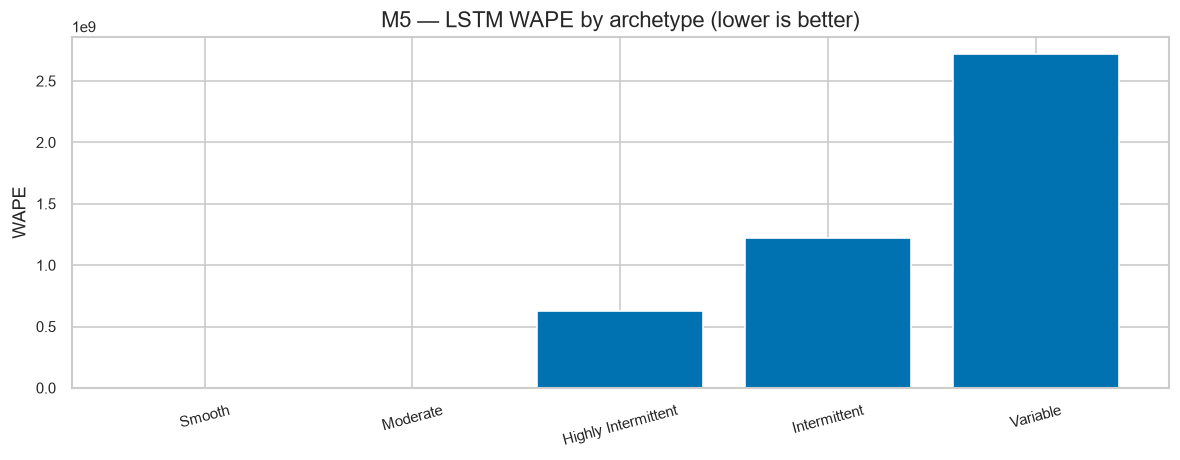

Saved: 03_lstm_by_archetype_m5.png


In [16]:
# M5 archetype breakdown for LSTM
M5_PROC = PROJ / "02_data/dataset_01_m5/processed"
prof = pd.read_csv(M5_PROC / "m5_series_profile.csv")
prof["id_eval"] = prof["item_id"].astype(str) + "_" + prof["store_id"].astype(str) + "_evaluation"
m5_lstm_series = per_series[(per_series["dataset"]=="m5") & (per_series["model"]=="LSTM")].merge(prof[["id_eval","archetype"]], left_on="series_id", right_on="id_eval", how="left")
if "archetype" in m5_lstm_series.columns:
    arch = m5_lstm_series.groupby("archetype")[["MAE","WAPE"]].mean().reset_index().sort_values("WAPE")
    print(arch.round(4).to_string(index=False))
    arch.to_csv(RES / "metrics_by_archetype_m5.csv", index=False)
    fig, ax = plt.subplots(figsize=(10,4))
    ax.bar(arch["archetype"], arch["WAPE"], color="#0072B2", edgecolor="white")
    ax.set_title("M5 — LSTM WAPE by archetype (lower is better)")
    ax.set_ylabel("WAPE"); ax.tick_params(axis="x", rotation=15)
    plt.tight_layout()
    plt.savefig(FIG_EXP / "03_lstm_by_archetype_m5.png", bbox_inches="tight", dpi=150)
    plt.show()
    print("Saved: 03_lstm_by_archetype_m5.png")
else:
    print("No archetype")

---

# 14. Business Implications

| Finding | Operational meaning |
|---|---|
| Global LSTM shares weekly motifs across 500 series | On Store Item, this can learn trend×seasonality interaction that additive TES and linear ARIMA miss — systematic Saturday bias may shrink. |
| Global pooling on sparse M5 | Masks intermittency: the model learns to predict small positive values (average of many zeros) instead of 0/ burst distribution — low WAPE but wrong inventory shape. |
| Direct 28-day forecast | Avoids recursive error accumulation, but cannot condition on its own intermediate predictions — may miss intra-horizon feedback. |
| Early stopping on last 28 windows of history | Prevents overfit to history noise; yet pooled validation may under-represent intermittent bursts. |

> A lower WAPE does not equal lower inventory cost. The inventory simulator (Notebook 10+) will test whether the error reduction — and its *shape* — translates to stockout/holding trade-offs under a common policy. A 0.1 WAPE gain concentrated on off-peak days has different business value than on peak days.

**Why this motivates the next rung:** LLM-based forecasting explicitly reasons about patterns and can incorporate richer context (not done here) — the ladder asks whether that reasoning pays off out-of-sample without inflating cost. LLM will be evaluated on the same frozen 112k points/dataset with the same leakage guards.

---

# 15. Artifacts Produced by This Notebook

- Forecasts: `06_results/lstm/all_forecasts.csv` (global direct 28, 224,000 rows = 112k per dataset), `m5_global_forecasts.csv`, `store_item_global_forecasts.csv`
- Metrics: `metrics_by_model.csv`, `metrics_by_series.csv`, `metrics_by_origin.csv`, `metrics_by_archetype_m5.csv`, `metrics_with_history.csv`
- Educational figures: `07_figures/model_explanations/lstm/` (3 figures)
- Experimental figures: `07_figures/lstm/` (3 figures)
- No frozen experiment change — same common window, series, horizon, origins, metrics, seed; global vs per-series choice clearly documented as primary.

In [17]:
figs_edu = sorted((PROJ / "07_figures/model_explanations/lstm").glob("*.png"))
figs_exp = sorted((PROJ / "07_figures/lstm").glob("*.png"))
print(f"Educational figures: {len(figs_edu)}")
for p in figs_edu:
    print(f"  {p.name}  ({p.stat().st_size/1024:.1f} KB)")
print(f"Experimental figures: {len(figs_exp)}")
for p in figs_exp:
    print(f"  {p.name}  ({p.stat().st_size/1024:.1f} KB)")
print(f"\nResults: {sorted(p.name for p in RES.glob('*'))}")
print("\nDatasets modified: NO")
print("Frozen experiment modified: NO")
print("Primary 500×8×28 per dataset = 112,000 points/dataset — verified above")
print("Global LSTM: 1 model per dataset/origin pooling 500 series, direct 28, lookback 28, hidden 32, batch 256, max 5 epochs early-stop patience 2, per-series scaling on history only")
print("Next: 09 LLM (deep teaching) — not started")

Educational figures: 3
  01_lookback_window.png  (80.4 KB)
  02_lstm_cell_gates.png  (79.7 KB)
  03_toy_direct_forecast.png  (58.7 KB)
Experimental figures: 4
  01_comparison_MAE.png  (58.9 KB)
  01_comparison_WAPE.png  (59.7 KB)
  02_wape_by_origin.png  (87.3 KB)
  03_lstm_by_archetype_m5.png  (31.7 KB)

Results: ['all_forecasts.csv', 'm5_global_forecasts.csv', 'metrics_by_archetype_m5.csv', 'metrics_by_model.csv', 'metrics_by_origin.csv', 'metrics_by_series.csv', 'metrics_with_history.csv', 'store_item_global_forecasts.csv']

Datasets modified: NO
Frozen experiment modified: NO
Primary 500×8×28 per dataset = 112,000 points/dataset — verified above
Global LSTM: 1 model per dataset/origin pooling 500 series, direct 28, lookback 28, hidden 32, batch 256, max 5 epochs early-stop patience 2, per-series scaling on history only
Next: 09 LLM (deep teaching) — not started
